In [3]:
import numpy as np
import gdstk as tk

from IPython.display import SVG

from gemkid.ue1 import layers
from gemkid import geometry as geom
from gemkid import mecstyle as mec

def sc(cell, scale=1):
    cell.write_svg("/tmp/blop.svg", background="#ffffff", scaling = scale)
    display(SVG("/tmp/blop.svg"))

mec.InductorDoubledConfig?

Init signature:
mec.InductorDoubledConfig(
    legs: int,
    leg_gap: float,
    leg_length: float,
    leg_width: float,
    leg_landing: float,
    leg_layer: tuple[int, int] | gemkid.layers.DrawingLayer,
    wiring_width: float,
    wiring_gap: float,
    wiring_layer: tuple[int, int] | gemkid.layers.DrawingLayer,
) -> None
Docstring:      InductorDoubledConfig(legs: int, leg_gap: float, leg_length: float, leg_width: float, leg_landing: float, leg_layer: tuple[int, int] | gemkid.layers.DrawingLayer, wiring_width: float, wiring_gap: float, wiring_layer: tuple[int, int] | gemkid.layers.DrawingLayer)
File:           ~/Workspace/research/gemkid/gemkid/mecstyle.py
Type:           ABCMeta
Subclasses:     

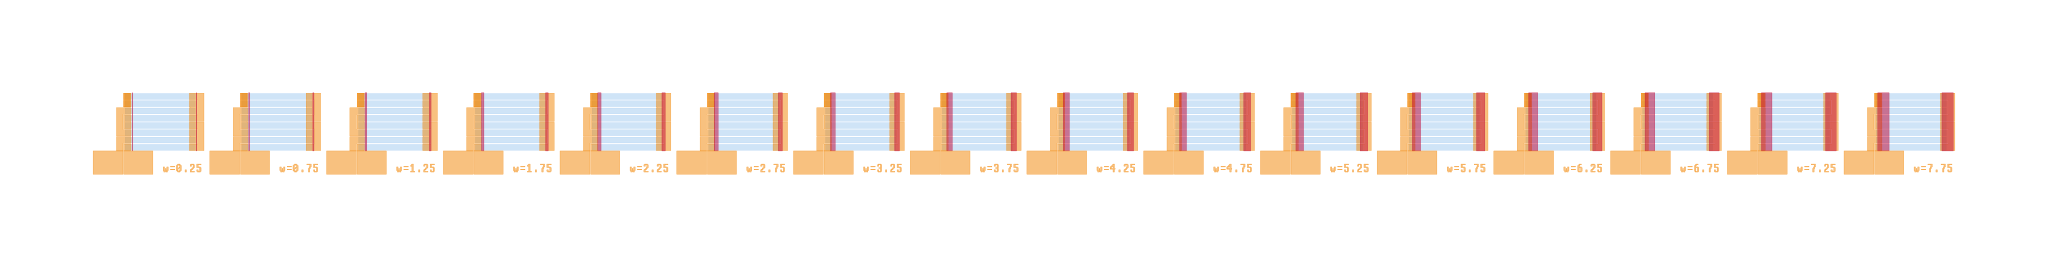

In [52]:
ec = []
def inductor_test(w, gw, gb):
    c  = mec.InductorDoubledConfig(4, gb, 40, 4, 4, layers.HF, 4.5, gw, layers.ATA_NB).draw(cellcache=None)
    c.add(tk.rectangle((4.5 + gw + 6 - w/2, 0), (4.5 + gw + 6 + w/2, (4*2) * (gb + 4) - gb + gw * 2), *layers.HF_CONTACT))
    c.add(tk.rectangle((4.5 + gw + 6 + 40 + 4 - w/2, 0), (4.5 + gw + 6 + 40 + 4 + w/2, (4*2) * (gb + 4) - gb + gw * 2), *layers.HF_CONTACT))
    
    c.add(tk.rectangle((-16, -16), (4.5, 0), *layers.ATA_NB))
    c.add(tk.rectangle((5+4+16, -16), (4.5 + gw, 0), *layers.ATA_NB))
    c.name = f"inductortest{w}{gw}{gb}"
    c.add(*tk.text(f"w={w}", 8, (32, -16)))
    ec.append(c)
    return c

inductors44 = tk.Cell("indusctors44")
for i, w in enumerate(np.arange(0.25, 8.25, 0.5)):
    inductors44.add(tk.Reference(inductor_test(w, 3.5, 4), (i*80, 0)))
inductors42 = tk.Cell("indusctors42")
for i, w in enumerate(np.arange(0.25, 8.25, 0.5)):
    inductors42.add(tk.Reference(inductor_test(w, 1.5, 2), (i*80, 0)))
inductors41 = tk.Cell("indusctors41")
for i, w in enumerate(np.arange(0.25, 8.25, 0.5)):
    inductors41.add(tk.Reference(inductor_test(w, 0.5, 1), (i*80, 0)))
sc(inductors41, 6)

In [53]:
def tlm(via, r = range(10, 110, 10), y = 0):
    a = 0
    p = []
    for g in r:
        p.extend(via.draw_polys((a, y), (a + via.landing_length*2 + g, y)))
        a += via.landing_length + g
    return p


tlms = tk.Cell("TLMs")
h = 0
for w in [32, 16, 8, 4, 2]:
    via = mec.ViaWire(w, layers.HF, False, w+50, 25, layers.ATA_NB, w, 25, layers.HF_CONTACT)
    vianb = mec.ViaWire(w, layers.HF_CONTACT, False, w+50, 25, layers.ATA_NB, w, 25, layers.HF_CONTACT)
    tlms.add(*tlm(via, range(10, 110, 10), h))
    tlms.add(*tlm(vianb, range(10, 110, 10), h + w + 50 + 16))
    tlms.add(*tk.text("w={:d}B ".format(w), 16, (-72, h - 8)))
    tlms.add(*tk.text("w={:d}NB".format(w), 16, (-72, h - 8 + w + 50 + 16)))

    h += 2 * (w + 50 + 16)

a = 0
for g in range(10, 110, 10):
    tlms.add(*tk.text("{:3d}".format(g), 16, (a + 25 + g / 2 - 16,  -64)))
    a += 25 + g

tlms.add(*tk.text("TLMs", 24, (-72, -64)))

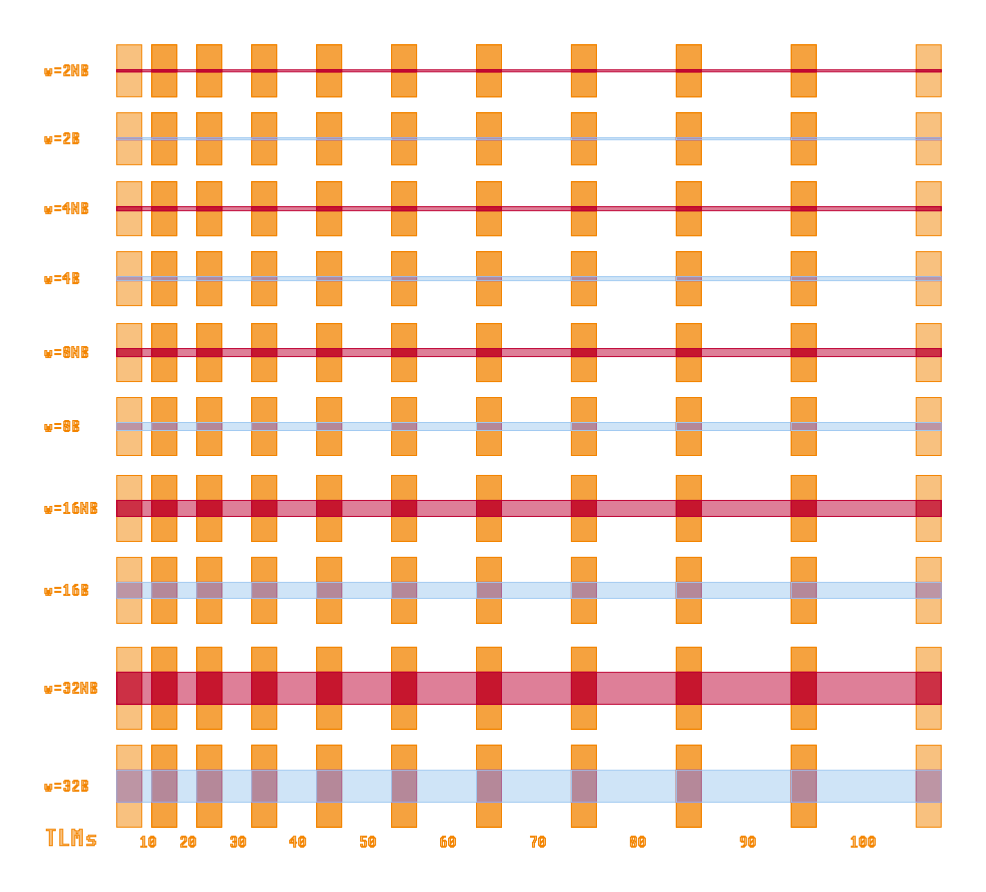

In [54]:
sc(tlms)

In [55]:
airtest = tk.Cell("Airtest")
for i, x in enumerate(np.arange(-2, 2.25, 0.25)):
    airtest.add(*tk.text("{:1.2f}".format(4 + x), 4, (i * (56 + 8), -20)))
    for j, y in enumerate(np.arange(-2, 2.25, 0.25)):
        via = mec.ViaWire(4, layers.HF, False, 8, 4, layers.ATA_NB, 4 + x, 4 + y, layers.CONTACT_CUT)
        airtest.add(*via.draw_polys((i * (56 + 8), j * 16), (i * (56 + 8) + 56, j * 16)))
        if i == 0:
            airtest.add(*tk.text("{:5.2f}".format(8 + y), 8, (-32, j * 16 - 4)))

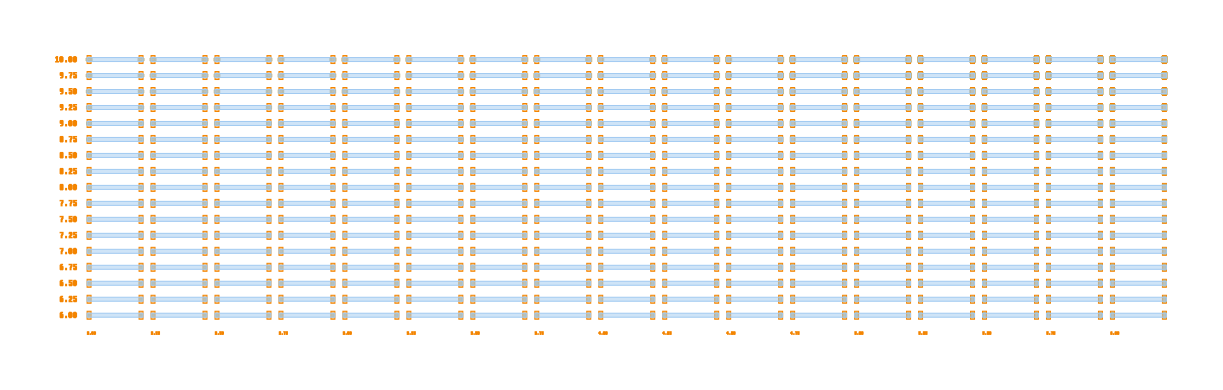

In [56]:
sc(airtest)

In [57]:
lib = tk.Library("UE1 Bridgemask")
lib.add(airtest, tlms, inductors41, inductors42, inductors44, *ec)
lib.write_gds("ue1bridgemask.gds")

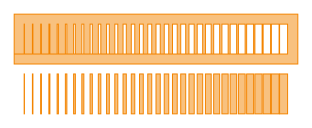

In [66]:
widthcal = tk.Cell("widthcal")
ws = np.arange(0.25, 8.25, 0.25)
neg = tk.rectangle((-10, 50), (len(ws)*8.25 + 10, 100))
rects = []
for i, w in enumerate(ws):
    widthcal.add(tk.rectangle((i*8.25, 0), (i*8.25 + w, 40)))
    rects.append(tk.rectangle((i*8.25, 60), (i*8.25 + w, 90)))

widthcal.add(*tk.boolean(neg, rects, "not"))
sc(widthcal)

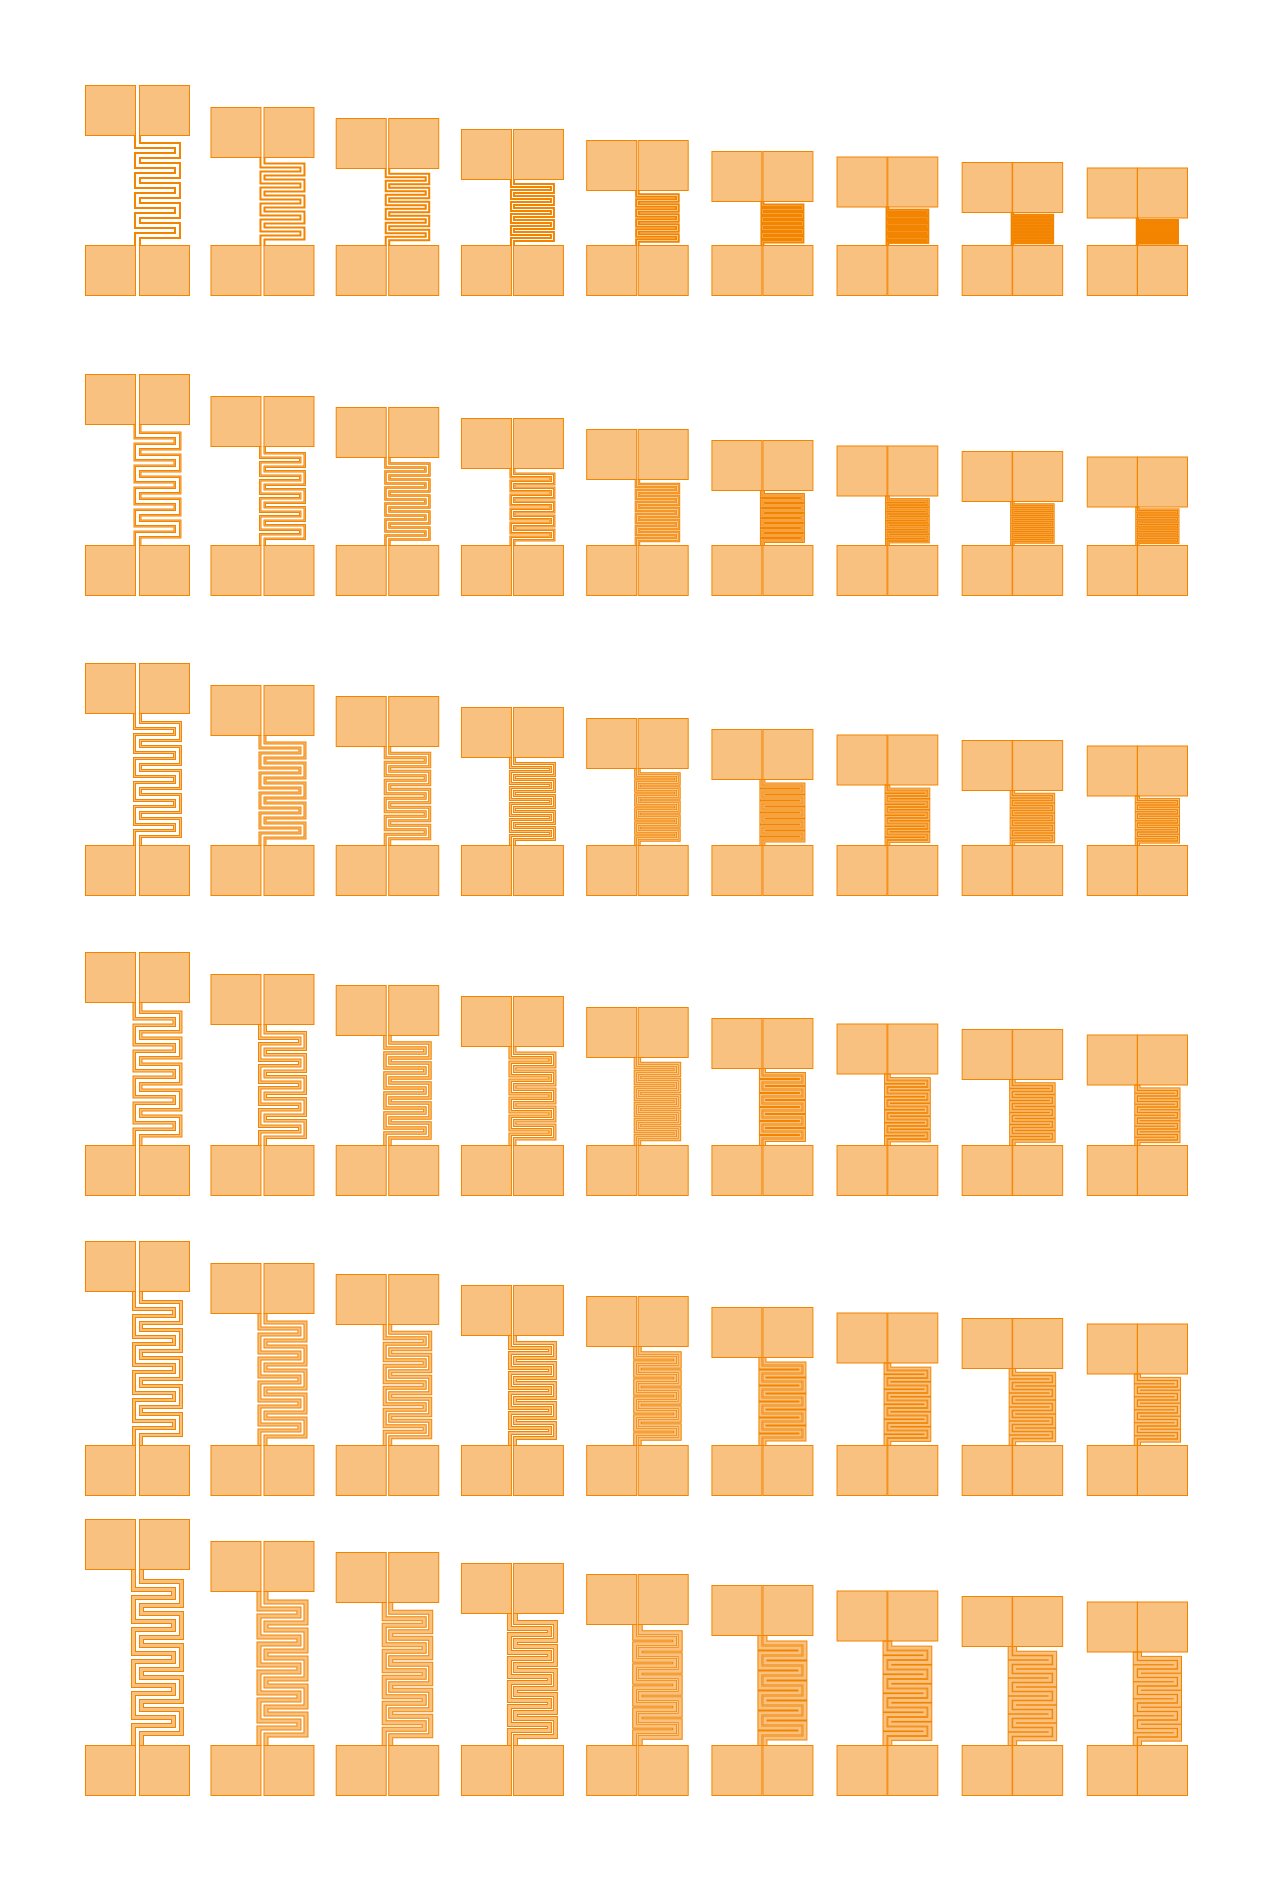

In [99]:
ec = []
def tracespace(t, s):
    ts = tk.Cell(f"tracespace{t}{s}")
    points = [(0, 0)]
    for i in range(1, 11):
        points.append((points[-1][0], points[-1][1] + 2 * t + 2*s))
        if i % 2:
            points.append((40, points[-1][1]))
        else:
            points.append((0, points[-1][1]))
    points.append((points[-1][0], points[-1][1] + 2 * t + 2*s))
    path = tk.FlexPath(
        points,
        [t, t], [-(t + s) / 2, (t + s) / 2],
        bend_radius = 0,
    )
    ts.add(path)
    ts.add(tk.rectangle((-s/2 - 50, -50), (-s/2, 0)))
    ts.add(tk.rectangle((+s/2, -50), (+s/2 + 50, 0)))
    ts.add(tk.rectangle((points[-1][0] - s/2 - 50, points[-1][1]), (points[-1][0] - s/2, points[-1][1] + 50)))
    ts.add(tk.rectangle((points[-1][0] + s/2, points[-1][1]), (points[-1][0] + s/2 + 50, points[-1][1] + 50)))
    return ts

ts = [4, 3, 2.5, 2, 1.5, 1]
ss = [4, 3, 2.5, 2, 1.5, 1, 0.75, 0.5, 0.25]

tsses = tk.Cell("tracespace")
for j, t in enumerate(ts):
    for i, s in enumerate(ss):
        c = tracespace(t, s)
        tsses.add(tk.Reference(c, (i*125, j*300)))
        ec.append(c)

sc(tsses)


In [100]:
lib = tk.Library("UE1 Test Structures")
lib.add(tsses, widthcal, *ec)
lib.write_gds("ue1ts.gds")